<a href="https://colab.research.google.com/github/jottaene13/An-lise-do-Censo-IBGE-2022---Benevides-PA-com-Proje-es-Futuras/blob/main/RANDOM_FOREST_VERS%C3%83O_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Célula 1 - Configuração inicial e importação de bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor  # Alterado para Regressor
from sklearn.metrics import mean_squared_error, r2_score  # Métricas de regressão
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from google.colab import files # Import files here

# Versões das bibliotecas para reproduzir
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
# Célula 2 - Upload do arquivo CSV
uploaded = files.upload()

if not uploaded:
    raise ValueError("Nenhum arquivo foi carregado. Por favor, faça o upload do arquivo CSV.")

file_name = next(iter(uploaded))
df = pd.read_csv(file_name, encoding='latin-1', delimiter=';', low_memory=False)

print("Primeiras linhas do dataset:")
display(df.head())

Saving vigilancia_parametros_basicos_2024.zip to vigilancia_parametros_basicos_2024.zip
Primeiras linhas do dataset:


,Região Geográfica,UF,Regional de Saúde,Município,Código IBGE,Número da amostra,Motivo da coleta,Tipo da Forma de Abastecimento,Código Forma de abastecimento,Nome da Forma de Abastecimento,...,Local,Latitude,Longitude,Parâmetro,'Análise realizada','Data da análise','LD','LQ',RESULTADO,'Providência'
0,SUL,SC,23ª REGIONAL DE SAÚDE- JOINVILLE,GARUVA,420580,242302000022,Rotina,SAA,S420580000001,AGUAS DE GARUVA,...,ESCOLA,NaN,NaN,Turbidez (uT),NaN,05/02/2024,NaN,NaN,"1,34",NaN
1,SUL,SC,23ª REGIONAL DE SAÚDE- JOINVILLE,GARUVA,420580,242302000056,Rotina,SAA,S420580000001,AGUAS DE GARUVA,...,ESCOLA,NaN,NaN,Fluoreto (mg/L),NaN,24/04/2024,NaN,NaN,"0,7",NaN
2,SUL,SC,23ª REGIONAL DE SAÚDE- JOINVILLE,GARUVA,420580,242302000162,Rotina,SAA,S420580000001,AGUAS DE GARUVA,...,MARIA CLARA,NaN,NaN,Cloro residual livre (mg/L),NaN,02/12/2024,NaN,NaN,"0,24",NaN
3,SUL,SC,23ª REGIONAL DE SAÚDE- JOINVILLE,GARUVA,420580,242302000001,Rotina,SAA,S420580000001,AGUAS DE GARUVA,...,SAUDE,NaN,NaN,Cloro residual livre (mg/L),NaN,15/01/2024,NaN,NaN,"1,73",NaN
4,SUL,SC,23ª REGIONAL DE SAÚDE- JOINVILLE,GARUVA,420580,242302000055,Rotina,SAA,S420580000001,AGUAS DE GARUVA,...,NaN,NaN,NaN,Fluoreto (mg/L),NaN,24/04/2024,NaN,NaN,"0,7",NaN


In [ ]:
# Célula 3 - Pré-processamento dos dados
# Parâmetros que serão usados como features ou targets
parametros = ['Coliformes Totais', 'turbidez', 'fluor', 'cloro residual livre',
              'cor aparente', 'pH']

# Filtra e pivota o DataFrame
df_filtered = df[df['Parâmetro'].isin(parametros)]
df_pivot = df_filtered.pivot_table(
    index=['Região Geográfica', 'UF', 'Regional de Saúde', 'Município', 'Código IBGE',
           'Número da amostra', 'Data da Coleta'],
    columns='Parâmetro',
    values='RESULTADO',
    aggfunc='first'
).reset_index()

print("\nEstrutura do DataFrame após pivot:")
display(df_pivot.head())


Estrutura do DataFrame após pivot:


Parâmetro,Região Geográfica,UF,Regional de Saúde,Município,Código IBGE,Número da amostra,Data da Coleta,pH
0,CENTRO-OESTE,DF,UNICA,AGUA QUENTE,530035,240102000858,2024/04/24 00:00:00.000,"6,9"
1,CENTRO-OESTE,DF,UNICA,AGUA QUENTE,530035,240102000859,2024/04/24 00:00:00.000,"6,9"
2,CENTRO-OESTE,DF,UNICA,AGUAS CLARAS,530020,240102000440,2024/03/19 00:00:00.000,"5,7"
3,CENTRO-OESTE,DF,UNICA,AGUAS CLARAS,530020,240102000441,2024/03/19 00:00:00.000,"6,8"
4,CENTRO-OESTE,DF,UNICA,AGUAS CLARAS,530020,240102000442,2024/03/19 00:00:00.000,"6,9"


In [ ]:
# Célula 4 - Limpeza e transformação dos dados
# Converte os resultados para valores numéricos

# Check the columns in df_pivot after the pivot operation
print("\nColunas no DataFrame após pivot:")
print(df_pivot.columns)

parametros_in_pivot = [param for param in parametros if param in df_pivot.columns]
print(f"\nParâmetros encontrados no DataFrame pivotado: {parametros_in_pivot}")


for param in parametros_in_pivot:
    df_pivot[param] = pd.to_numeric(df_pivot[param].astype(str).str.replace(',', '.'), errors='coerce')

# Remove linhas com muitos valores faltantes
df_clean = df_pivot.dropna(subset=parametros_in_pivot, thresh=len(parametros_in_pivot)//2)


# Preenche valores faltantes com a mediana
imputer = SimpleImputer(strategy='median')
df_clean[parametros_in_pivot] = imputer.fit_transform(df_clean[parametros_in_pivot])

# Codifica variáveis categóricas
le = LabelEncoder()
categorical_cols = ['Região Geográfica', 'UF', 'Regional de Saúde', 'Município']
for col in categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Mostra estatísticas descritivas
print("\nEstatísticas descritivas dos parâmetros:")
display(df_clean[parametros_in_pivot].describe())


Colunas no DataFrame após pivot:
Index(['Região Geográfica', 'UF', 'Regional de Saúde', 'Município',
       'Código IBGE', 'Número da amostra', 'Data da Coleta', 'pH'],
      dtype='object', name='Parâmetro')

Parâmetros encontrados no DataFrame pivotado: ['pH']

Estatísticas descritivas dos parâmetros:


Parâmetro,pH
count,284034.000000
mean,6.651570
std,1.223426
min,0.000000
25%,6.000000
50%,7.000000
75%,7.180000
max,14.000000


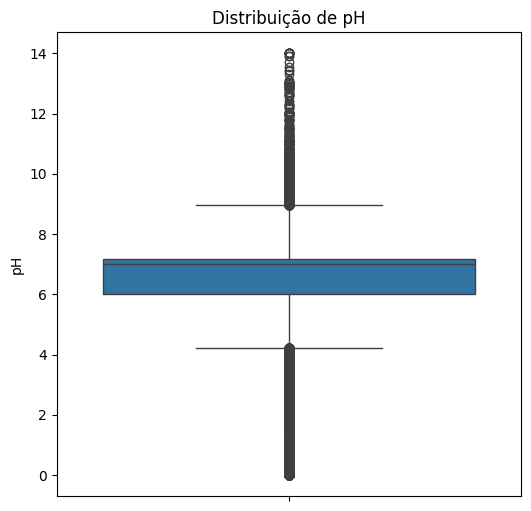

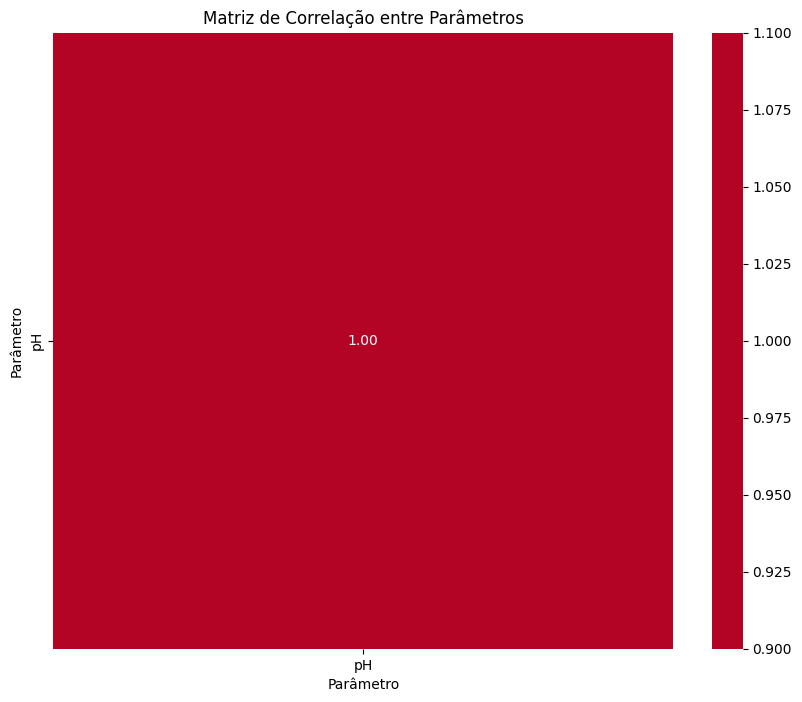

In [ ]:
# Célula 5 - Análise exploratória dos dados
plt.figure(figsize=(15, 10))

# Boxplots dos parâmetros
for i, param in enumerate(parametros_in_pivot):
    if param in df_clean.columns:
        plt.subplot(2, 3, i+1)
        sns.boxplot(y=df_clean[param])
        plt.title(f'Distribuição de {param}')

plt.tight_layout()
plt.show()

# Matriz de correlação
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[parametros_in_pivot].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlação entre Parâmetros')
plt.show()

In [ ]:
# Célula 6 - Preparação dos dados para regressão
# Seleciona o parâmetro alvo para regressão (pode ser alterado)
target_param = 'pH'  # Altere para o parâmetro que deseja prever
features_to_exclude = [target_param, 'Número da amostra'] + parametros
if 'Data da Coleta_timestamp' in df_clean.columns and 'Data da Coleta_timestamp' not in features_to_exclude:
    features = [col for col in df_clean.columns if col not in features_to_exclude]
else:
    features = [col for col in df_clean.columns if col not in features_to_exclude]


X = df_clean[features]
y = df_clean[target_param]

# Divide em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"\nParâmetro alvo: {target_param}")
print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")
print("\nColunas usadas como features (X):")
print(X_train.columns)


Parâmetro alvo: pH
Tamanho do conjunto de treino: 198823
Tamanho do conjunto de teste: 85211

Colunas usadas como features (X):
Index(['Região Geográfica', 'UF', 'Regional de Saúde', 'Município',
       'Código IBGE', 'Data da Coleta_timestamp'],
      dtype='object', name='Parâmetro')



Métricas de Regressão:
RMSE: 0.7254
R²: 0.6479


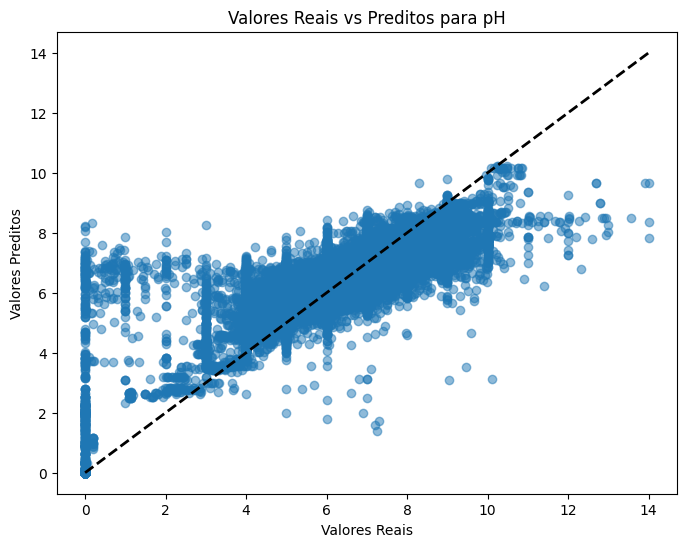

In [ ]:
# Célula 7 - Treinamento do modelo Random Forest Regressor
# Cria e treina o modelo
rf_regressor = RandomForestRegressor(
    n_estimators=200,      # Aumentado para regressão
    max_depth=15,          # Profundidade maior
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',   # Alterado para 'sqrt'
    random_state=42,
    n_jobs=-1             # Usa todos os núcleos do processador
)

rf_regressor.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred = rf_regressor.predict(X_test)

# Avaliação do modelo
print("\nMétricas de Regressão:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

# Gráfico de dispersão valores reais vs preditos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title(f'Valores Reais vs Preditos para {target_param}')
plt.show()

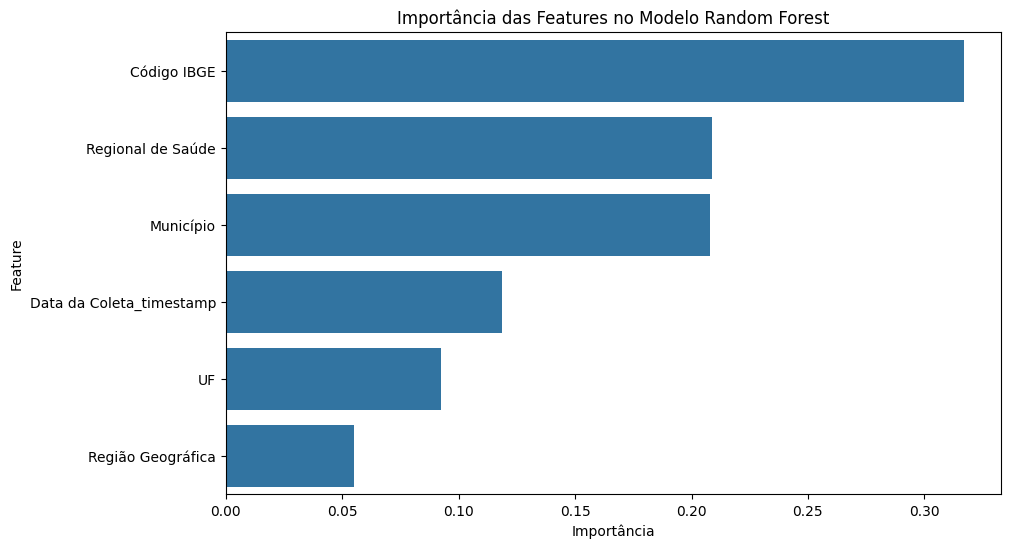

,Feature,Importance
4,Código IBGE,0.316968
2,Regional de Saúde,0.208663
3,Município,0.207815
5,Data da Coleta_timestamp,0.118763
1,UF,0.092536
0,Região Geográfica,0.055255


In [ ]:
# Célula 8 - Análise de importância das features
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))  # Mostra apenas as top 15
plt.title('Importância das Features no Modelo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.show()

display(feature_importance.head(15))

In [ ]:
# Célula 9 - Salvando o modelo e resultados
from joblib import dump

# Salva o modelo treinado
dump(rf_regressor, f'random_forest_regressor_{target_param}.joblib')

# Salva os dados processados
df_clean.to_csv('water_quality_processed_regression.csv', index=False)

# Faz download dos arquivos
files.download(f'random_forest_regressor_{target_param}.joblib')
files.download('water_quality_processed_regression.csv')

print("Modelo e dados processados salvos com sucesso!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo e dados processados salvos com sucesso!
